In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']=(12,5)
plt.rcParams['font.family']='DejaVu Sans'
sns.set_theme(style='darkgrid',palette='bright')

conn=sqlite3.connect('../data/ipl.db')
print('✅ Connected to ipl.db')

✅ Connected to ipl.db


In [2]:
##📅Secton-1Sesason Overview
# How has ipl grown over years?

In [3]:
season_df=pd.read_sql("""
    SELECT
        season,
        COUNT(DISTINCT match_id) as total_matches,
        SUM(runs_total)as total_runs,
        ROUND(AVG(runs_total),2)as avg_runs_per_ball
    FROM deliveries
    WHERE innings IN (1,2)
    GROUP BY season
    ORDER BY season
        
""",conn)
print(season_df.to_string(index=False))

 season  total_matches  total_runs  avg_runs_per_ball
   2008             58       17937               1.33
   2009             57       16320               1.20
   2010             60       18864               1.30
   2011             73       21154               1.24
   2012             74       22453               1.26
   2013             76       22541               1.24
   2014             60       18909               1.32
   2015             59       18332               1.34
   2016             60       18862               1.34
   2017             59       18769               1.36
   2018             60       19901               1.39
   2019             60       19400               1.36
   2020             60       19352               1.33
   2021             60       18622               1.29
   2022             74       24395               1.36
   2023             74       25688               1.44
   2024             71       25971               1.52
   2025             74      

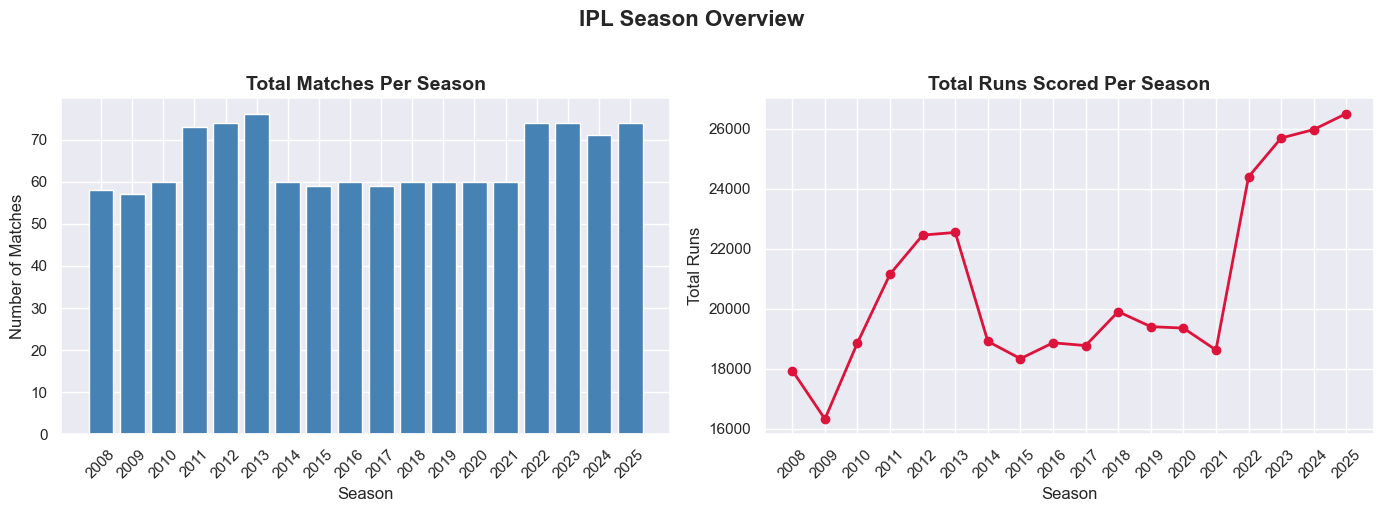

✅ Saved: report/01_season_overview.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(season_df['season'], season_df['total_matches'], 
            color='steelblue', edgecolor='white')
axes[0].set_title('Total Matches Per Season', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Number of Matches')
axes[0].set_xticks(season_df['season'])
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(season_df['season'], season_df['total_runs'], 
             marker='o', color='crimson', linewidth=2)
axes[1].set_title('Total Runs Scored Per Season', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Total Runs')
axes[1].set_xticks(season_df['season'])
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('IPL Season Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../report/01_season_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/01_season_overview.png')

In [5]:
#Section-2   TOP BATSMEN
# who are all time run scorers?

In [6]:
top_batsmen = pd.read_sql("""
    SELECT
        batter,
        SUM(runs_batter)AS total_runs,
        COUNT(DISTINCT match_id)AS matches,
        SUM(CASE WHEN runs_batter=4 THEN 1 ELSE 0 END) AS fours,
        SUM(CASE WHEN runs_batter=6 THEN 1 ELSE 0 END) AS sixes,
        ROUND(
            CAST(SUM(runs_batter) AS FLOAT) /
            NULLIF(SUM(valid_ball),0) * 100, 2
        ) AS strike_rate
    FROM deliveries
    WHERE innings IN (1,2)
    GROUP BY batter
    ORDER BY total_runs DESC
    LIMIT 15
""", conn)

print(top_batsmen.to_string(index=False))

        batter  total_runs  matches  fours  sixes  strike_rate
       V Kohli        8661      259    772    292       133.23
     RG Sharma        7046      266    640    303       132.59
      S Dhawan        6769      221    768    153       127.67
     DA Warner        6565      184    663    236       140.43
      SK Raina        5528      200    506    203       137.44
      MS Dhoni        5439      241    375    264       138.22
      KL Rahul        5222      135    452    208       136.45
AB de Villiers        5162      170    413    251       152.18
     AM Rahane        5032      183    515    123       125.14
      CH Gayle        4965      141    405    357       149.64
    RV Uthappa        4952      197    481    182       130.94
    KD Karthik        4842      233    466    161       135.74
  F du Plessis        4773      147    440    174       136.14
     SV Samson        4704      171    379    219       139.67
     AT Rayudu        4348      185    359    173      

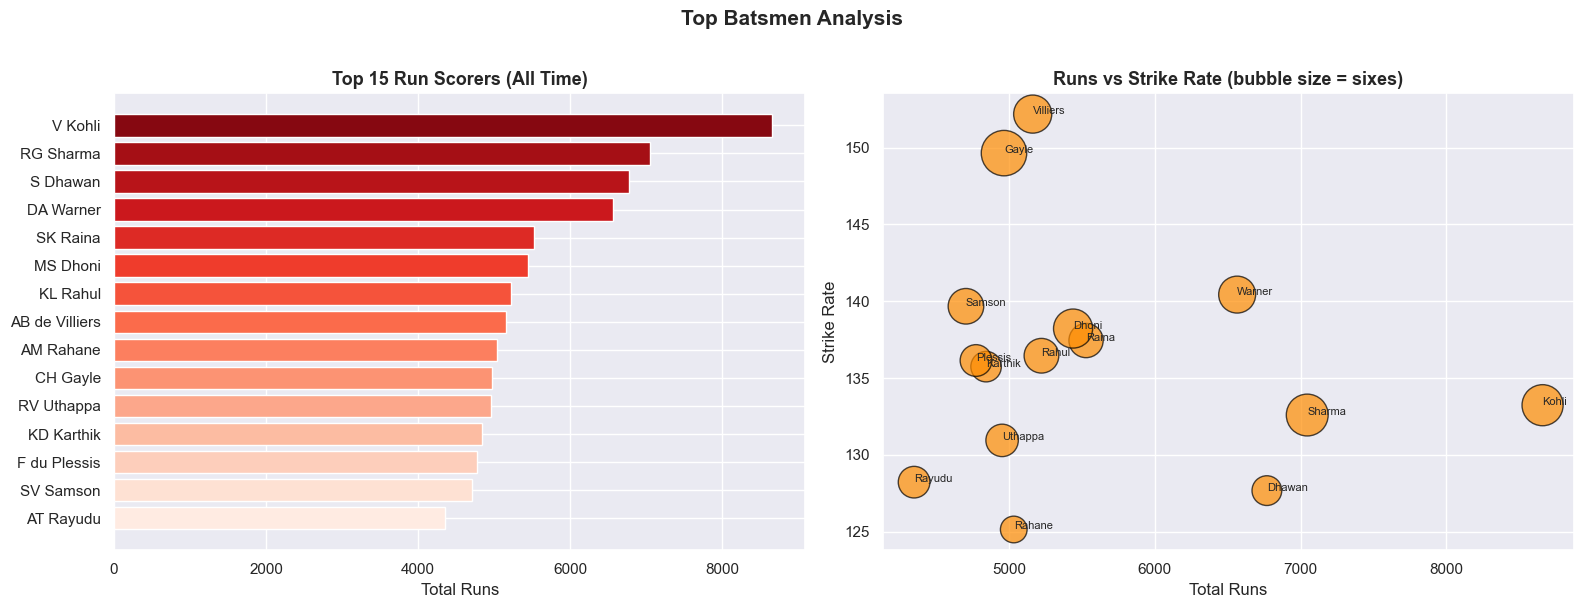

✅ Saved: report/02_top_batsmen.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Reds_r', len(top_batsmen))
axes[0].barh(top_batsmen['batter'], top_batsmen['total_runs'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Run Scorers (All Time)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Runs')

axes[1].scatter(
    top_batsmen['total_runs'],
    top_batsmen['strike_rate'],
    s=top_batsmen['sixes']*3,#INCREASE THE BUBBLE SIZE WHO HIT MAX NOS OF SIXES
    alpha=0.7, color='darkorange', edgecolors='black'
)
for _, row in top_batsmen.iterrows():
    axes[1].annotate(row['batter'].split()[-1],
                     (row['total_runs'], row['strike_rate']),
                     fontsize=8, ha='left')

axes[1].set_title('Runs vs Strike Rate (bubble size = sixes)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Runs')
axes[1].set_ylabel('Strike Rate')

plt.suptitle('Top Batsmen Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/02_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/02_top_batsmen.png')

In [8]:
#Section-3   TOP BOWLERS
#who took most wickets

top_bowlers=pd.read_sql("""
    SELECT
        bowler,
        SUM(bowler_wicket)AS total_wickets,
        COUNT(DISTINCT match_id)AS matches,
        ROUND(SUM(valid_ball)/6.0,1)AS overs_bowled,
        ROUND(CAST(SUM(runs_bowler)AS FLOAT)/ NULLIF(SUM(valid_ball)/6.0,0),2)AS economy_rate
    FROM deliveries
    WHERE innings IN (1,2)
    GROUP BY bowler
    HAVING total_wickets>50
    ORDER BY total_wickets DESC
    LIMIT 15
        
""",conn)
print(top_bowlers.to_string(index=False))

         bowler  total_wickets  matches  overs_bowled  economy_rate
      YS Chahal            221      172         631.8          7.96
        B Kumar            198      190         703.7          7.69
      SP Narine            192      187         724.2          6.80
      PP Chawla            192      191         641.7          7.96
       R Ashwin            187      217         785.0          7.20
      JJ Bumrah            183      145         556.2          7.25
       DJ Bravo            183      158         520.0          8.38
       A Mishra            174      162         561.8          7.38
     SL Malinga            170      122         471.2          7.14
      RA Jadeja            170      225         676.0          7.67
    Rashid Khan            158      136         531.5          7.09
       HV Patel            151      116         404.0          8.86
Harbhajan Singh            150      160         569.3          7.08
 Sandeep Sharma            146      136         

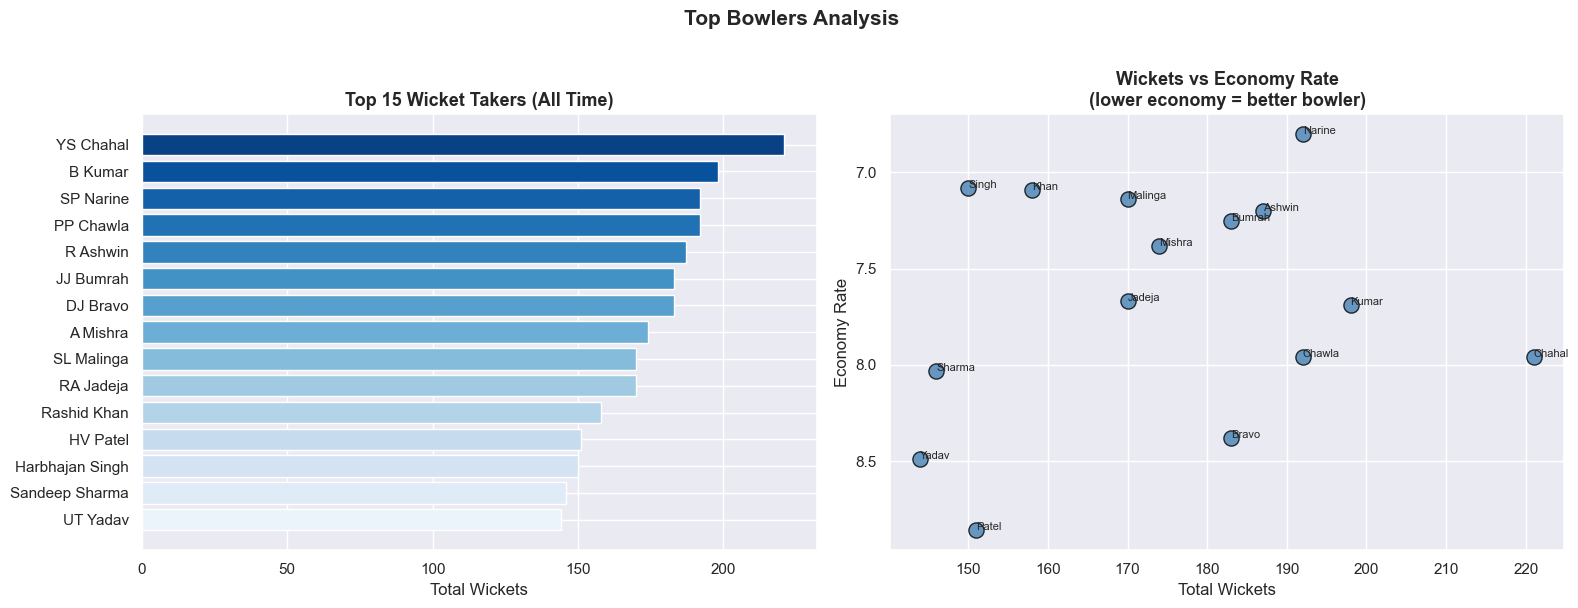

✅ Saved: report/03_top_bowlers.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Blues_r', len(top_bowlers))
axes[0].barh(top_bowlers['bowler'], top_bowlers['total_wickets'], color=colors)
axes[0].invert_yaxis()
axes[0].set_title('Top 15 Wicket Takers (All Time)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Wickets')

axes[1].scatter(
    top_bowlers['total_wickets'],
    top_bowlers['economy_rate'],
    s=120, alpha=0.8, color='steelblue', edgecolors='black'
)
for _, row in top_bowlers.iterrows():
    axes[1].annotate(row['bowler'].split()[-1],
                     (row['total_wickets'], row['economy_rate']),
                     fontsize=8)
axes[1].set_title('Wickets vs Economy Rate\n(lower economy = better bowler)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Wickets')
axes[1].set_ylabel('Economy Rate')
axes[1].invert_yaxis()

plt.suptitle('Top Bowlers Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/03_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/03_top_bowlers.png')

In [10]:
#SECTION-4 Team Performance


In [11]:
team_df=pd.read_sql("""
    SELECT
        batting_team,
        season,
        SUM(runs_total)AS runs_scored,
        COUNT(DISTINCT match_id)AS matches_played
    FROM deliveries
    WHERE innings IN (1,2)
    GROUP BY batting_team,season
    ORDER BY season,runs_scored DESC
""",conn)
team_totals = team_df.groupby('batting_team')['runs_scored'].sum().sort_values(ascending=False).head(10)
print(team_totals)


batting_team
Mumbai Indians                 45045
Kolkata Knight Riders          41297
Chennai Super Kings            41061
Royal Challengers Bangalore    37651
Rajasthan Royals               37315
Sunrisers Hyderabad            31553
Kings XI Punjab                30017
Delhi Daredevils               24285
Delhi Capitals                 17366
Punjab Kings                   12798
Name: runs_scored, dtype: int64


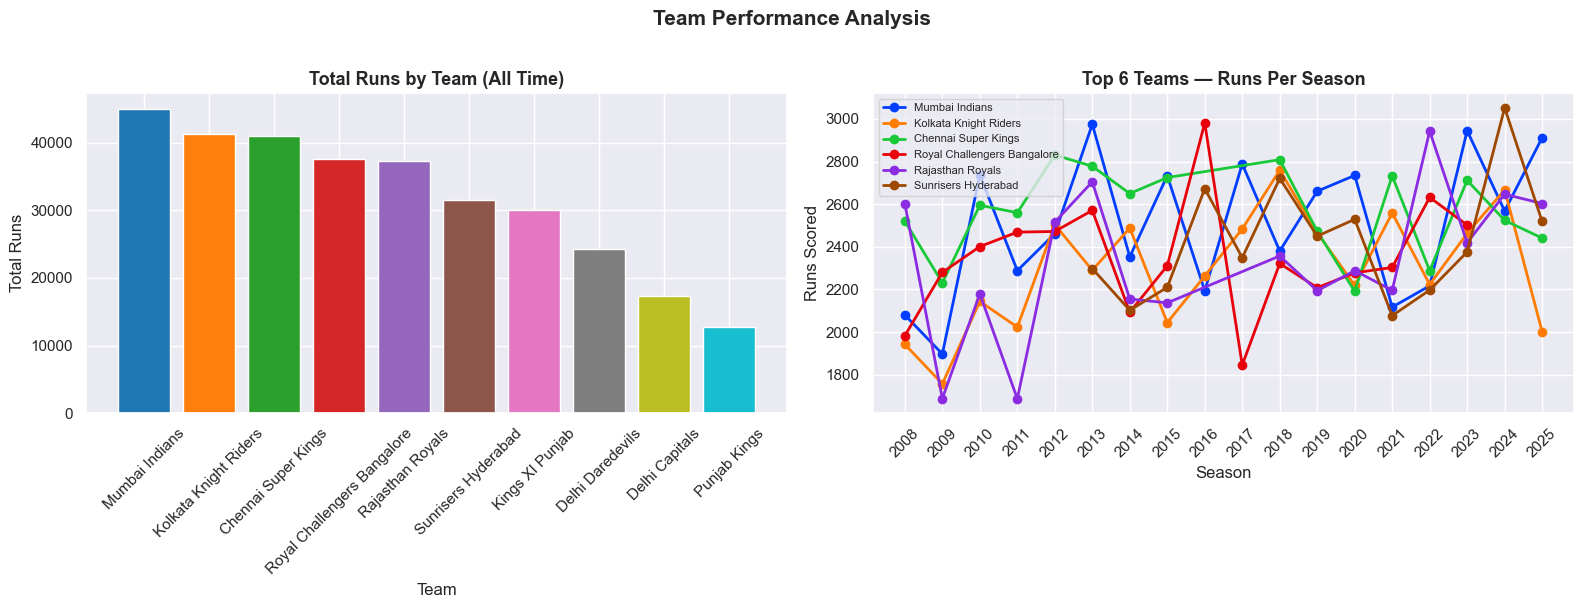

✅ Saved: report/04_team_performance.png


In [12]:
top_teams = team_totals.head(6).index.tolist()
team_trend = team_df[team_df['batting_team'].isin(top_teams)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('tab10', len(team_totals))
axes[0].bar(team_totals.index, team_totals.values, color=colors)
axes[0].set_title('Total Runs by Team (All Time)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Team')
axes[0].set_ylabel('Total Runs')
axes[0].tick_params(axis='x', rotation=45)

seasons = sorted(team_df['season'].unique())
for team in top_teams:
    t = team_trend[team_trend['batting_team']==team]
    axes[1].plot(t['season'], t['runs_scored'], marker='o', label=team, linewidth=2)
axes[1].set_title('Top 6 Teams — Runs Per Season', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Runs Scored')
axes[1].set_xticks(seasons)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Team Performance Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/04_team_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/04_team_performance.png')

In [13]:
#SECTION_5  DEATH BOWELER AND BATSMEN

In [14]:
death_bat = pd.read_sql("""
    SELECT
        batter,
        SUM(runs_batter)  AS runs,
        SUM(valid_ball)   AS balls,
        SUM(CASE WHEN runs_batter=6 THEN 1 ELSE 0 END) AS sixes,
        ROUND(CAST(SUM(runs_batter) AS FLOAT)/NULLIF(SUM(valid_ball),0)*100,2) AS strike_rate
    FROM deliveries
    WHERE over >= 15 AND innings IN (1,2)
    GROUP BY batter
    HAVING balls >= 200
    ORDER BY strike_rate DESC
    LIMIT 12
""", conn)

death_bowl = pd.read_sql("""
    SELECT
        bowler,
        SUM(bowler_wicket) AS wickets,
        SUM(valid_ball)    AS balls,
        ROUND(CAST(SUM(runs_bowler) AS FLOAT)/NULLIF(SUM(valid_ball)/6.0,0),2) AS economy
    FROM deliveries
    WHERE over >= 15 AND innings IN (1,2)
    GROUP BY bowler
    HAVING balls >= 100
    ORDER BY economy ASC
    LIMIT 12
""", conn)

print('--- Top Death Over Batsmen ---')
print(death_bat.to_string(index=False))
print('\n--- Top Death Over Bowlers ---')
print(death_bowl.to_string(index=False))

--- Top Death Over Batsmen ---
        batter  runs  balls  sixes  strike_rate
AB de Villiers  1868    829    140       225.33
      CH Gayle   581    280     50       207.50
       RR Pant  1000    492     74       203.25
     H Klaasen   553    277     36       199.64
    JC Buttler   729    368     49       198.10
    AD Russell  1432    724    128       197.79
Shashank Singh   424    219     28       193.61
     JM Sharma   424    219     33       193.61
      TH David   676    350     51       193.14
      RK Singh   608    317     40       191.80
     SV Samson   780    407     53       191.65
       V Kohli  1507    803     89       187.67

--- Top Death Over Bowlers ---
       bowler  wickets  balls  economy
Sohail Tanvir       16    103     6.82
    SP Narine       75   1051     7.35
 DE Bollinger       23    234     7.49
     A Kumble       17    167     7.62
      J Botha        8    106     7.70
   SL Malinga      108   1117     7.86
     M Kartik        6    154     8.03
 

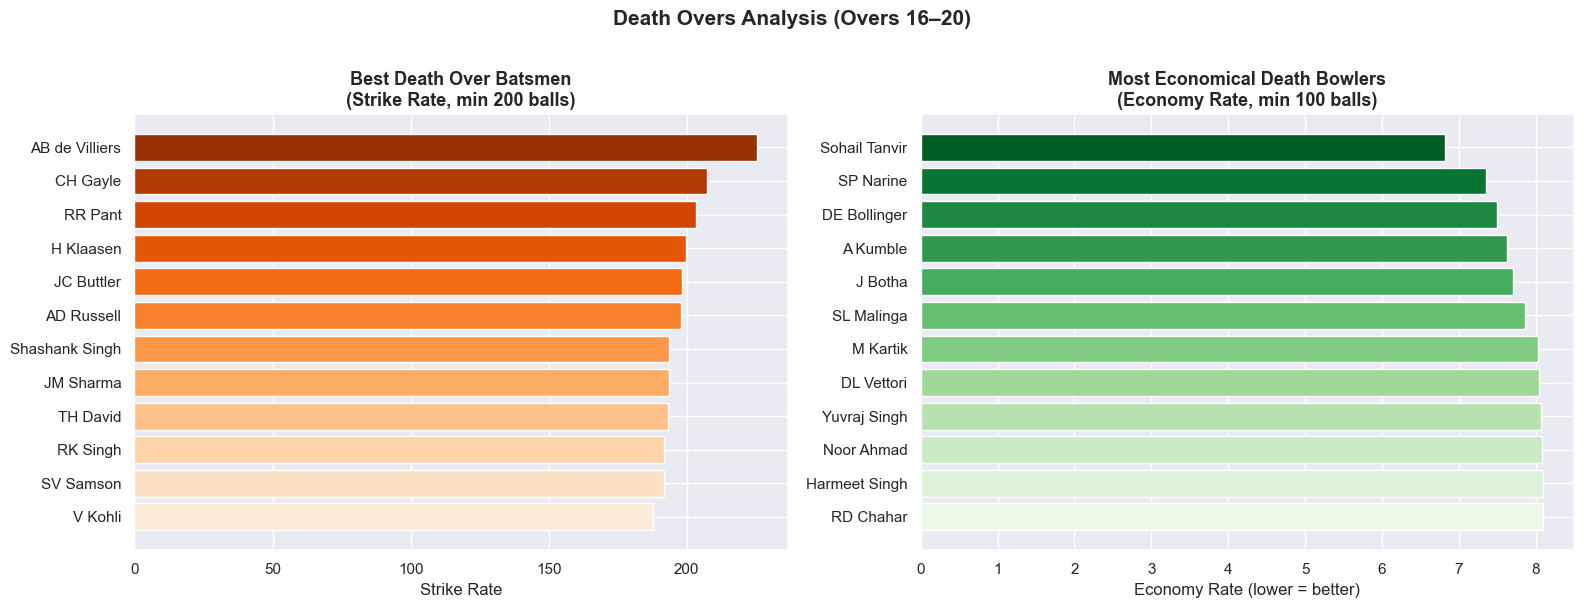

✅ Saved: report/05_death_overs.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(death_bat['batter'], death_bat['strike_rate'],
             color=sns.color_palette('Oranges_r', len(death_bat)))
axes[0].invert_yaxis()
axes[0].set_title('Best Death Over Batsmen\n(Strike Rate, min 200 balls)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Strike Rate')

axes[1].barh(death_bowl['bowler'], death_bowl['economy'],
             color=sns.color_palette('Greens_r', len(death_bowl)))
axes[1].invert_yaxis()
axes[1].set_title('Most Economical Death Bowlers\n(Economy Rate, min 100 balls)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Economy Rate (lower = better)')

plt.suptitle('Death Overs Analysis (Overs 16–20)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/05_death_overs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/05_death_overs.png')

In [16]:
#section-6
#VENUE ANALYSIS

In [17]:
venue_df = pd.read_sql("""
    SELECT
        venue,
        COUNT(DISTINCT match_id)   AS matches,
        ROUND(AVG(runs_total)*6,2) AS avg_runs_per_over,
        SUM(bowler_wicket)         AS total_wickets,
        ROUND(
            CAST(SUM(bowler_wicket) AS FLOAT)/
            NULLIF(COUNT(DISTINCT match_id),0), 2
        ) AS wickets_per_match
    FROM deliveries
    WHERE innings IN (1,2) AND event_name IS NOT NULL
    GROUP BY venue
    HAVING matches >= 10
    ORDER BY avg_runs_per_over DESC
    LIMIT 15
""", conn)

print(venue_df.to_string(index=False))

                                                                venue  matches  avg_runs_per_over  total_wickets  wickets_per_match
                                                Eden Gardens, Kolkata       23               9.43            256              11.13
                                          Arun Jaitley Stadium, Delhi       23               9.31            256              11.13
                 Rajiv Gandhi International Stadium, Uppal, Hyderabad       19               9.26            196              10.32
                                     M Chinnaswamy Stadium, Bengaluru       19               9.24            217              11.42
                                       Sawai Mansingh Stadium, Jaipur       17               9.04            164               9.65
                                     Narendra Modi Stadium, Ahmedabad       33               8.91            380              11.52
                                                M.Chinnaswamy Stadium       

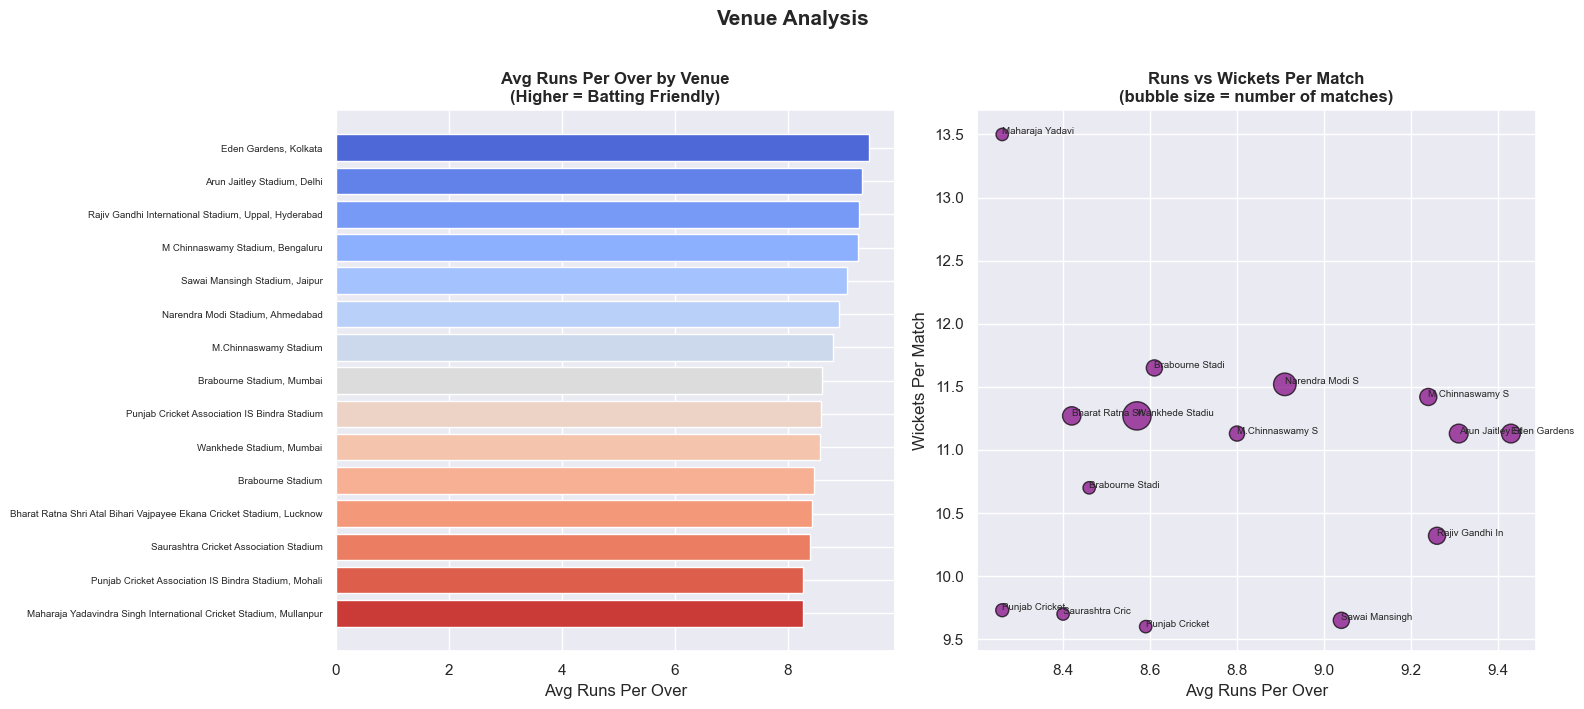

✅ Saved: report/06_venue_analysis.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(venue_df['venue'], venue_df['avg_runs_per_over'],
             color=sns.color_palette('coolwarm', len(venue_df)))
axes[0].invert_yaxis()
axes[0].set_title('Avg Runs Per Over by Venue\n(Higher = Batting Friendly)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Avg Runs Per Over')
axes[0].tick_params(axis='y', labelsize=7)

axes[1].scatter(
    venue_df['avg_runs_per_over'],
    venue_df['wickets_per_match'],
    s=venue_df['matches']*8,
    alpha=0.7, color='purple', edgecolors='black'
)
for _, row in venue_df.iterrows():
    axes[1].annotate(
        row['venue'].split(',')[0][:15],
        (row['avg_runs_per_over'], row['wickets_per_match']),
        fontsize=7
    )
axes[1].set_title('Runs vs Wickets Per Match\n(bubble size = number of matches)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Avg Runs Per Over')
axes[1].set_ylabel('Wickets Per Match')

plt.suptitle('Venue Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../report/06_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: report/06_venue_analysis.png')